In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
df=pd.read_csv("credit_card_fraud_10k.csv")

In [3]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.shape



(10000, 10)

In [5]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [8]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

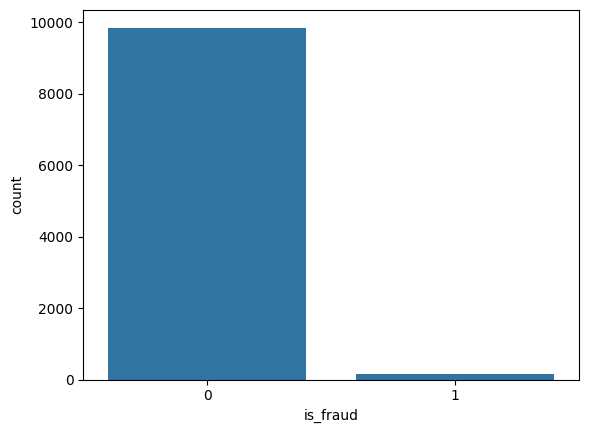

In [14]:
##visualising
sns.countplot(
    x='is_fraud',data=df
)
plt.show()

In [15]:
df['merchant_category'].value_counts()

merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64

In [16]:
df.drop(
    'transaction_id',
    axis=1,
    inplace=True
)

In [17]:
X=df.drop("is_fraud",axis=1)

In [18]:
X

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
0,84.47,22,Electronics,0,0,66,3,40
1,541.82,3,Travel,1,0,87,1,64
2,237.01,17,Grocery,0,0,49,1,61
3,164.33,4,Grocery,0,1,72,3,34
4,30.53,15,Food,0,0,79,0,44
...,...,...,...,...,...,...,...,...
9995,350.91,22,Food,0,0,99,4,37
9996,410.04,5,Clothing,0,0,70,3,25
9997,527.75,21,Electronics,0,0,44,2,45
9998,91.20,2,Electronics,0,0,38,0,37


In [19]:
Y=df["is_fraud"]

In [20]:
Y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: is_fraud, Length: 10000, dtype: int64

In [21]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   amount               10000 non-null  float64
 1   transaction_hour     10000 non-null  int64  
 2   merchant_category    10000 non-null  str    
 3   foreign_transaction  10000 non-null  int64  
 4   location_mismatch    10000 non-null  int64  
 5   device_trust_score   10000 non-null  int64  
 6   velocity_last_24h    10000 non-null  int64  
 7   cardholder_age       10000 non-null  int64  
dtypes: float64(1), int64(6), str(1)
memory usage: 625.1 KB


In [22]:
categorical_features = [
    "merchant_category"
]

In [23]:
numerical_features = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age"
]

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [28]:
## creating preprocssing pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(

    transformers=[
        
        ("num",
         StandardScaler(),
         numerical_features),

        ("cat",
         OneHotEncoder(
             handle_unknown="ignore"
         ),
         categorical_features)
    ]
)

In [29]:
X_trained_scaled=preprocessor.fit_transform(X_train)

In [30]:
X_test_scaled=preprocessor.transform(X_test)

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_trained_scaled,
    Y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
y_pred = model.predict(
    X_test_scaled
)

In [42]:
cm=confusion_matrix(
    Y_test,
    y_pred
)

In [44]:
p_score=precision_score(
    Y_test,
    y_pred
)

In [45]:
rc_score=recall_score(
    Y_test,
    y_pred
)

In [46]:
f1_score=f1_score(
    Y_test,
    y_pred
)

In [48]:
from sklearn.metrics import roc_auc_score

roc_auc_score=roc_auc_score(
    Y_test,
    y_pred
    )

In [50]:
score=accuracy_score(y_pred,Y_test)

In [51]:
print(cm);
print("p_score",p_score)
print("rc_scoe",rc_score)
print("F_score",f1_score)
print("roc_auc_score",roc_auc_score)
print("Accuracy",score)


[[1970    0]
 [  14   16]]
p_score 1.0
rc_scoe 0.5333333333333333
F_score 0.6956521739130435
roc_auc_score 0.7666666666666666
Accuracy 0.993
